# CIFAR-10 Image Classification using ANN (Multi-class)

This notebook builds an Artificial Neural Network using **TensorFlow / Keras** to classify **CIFAR-10** color images into 10 categories.

**Dataset**: CIFAR-10 - 60,000 32x32 color images in 10 classes (50,000 train + 10,000 test), loaded from `Cifar_data/train.csv` and `Cifar_data/test.csv`. `test.csv` has no labels, so we split `train.csv` into train/test sets ourselves.

**Target**:
- `label` - The object class shown in the image (0 through 9) -> 10 classes
  - 0: airplane, 1: automobile, 2: bird, 3: cat, 4: deer, 5: dog, 6: frog, 7: horse, 8: ship, 9: truck

**Features**:
- 3072 pixel intensities (32 x 32 x 3 channels, flattened) with values in [0, 255]

**Pipeline**:
- Load CIFAR-10 pixel data from CSV, split into train/test
- Visualize sample images & class distribution
- Normalize pixels to [0, 1] (already flattened, 3072 columns)
- `Dense` + `BatchNormalization` + `Dropout` layers
- `softmax` output + `sparse_categorical_crossentropy` loss (works directly with integer labels)
- `EarlyStopping` callback
- Evaluate with accuracy, classification report and confusion matrix

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

sns.set_style('whitegrid')

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

I0000 00:00:1787286465.800409   18587 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787286465.800982   18587 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787286465.855646   18587 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787286467.656265   18587 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

## 2. Load the Dataset

`Cifar_data/train.csv` contains 3072 pixel columns plus a `label` column. `Cifar_data/test.csv` has the same 3072 pixel columns but **no** `label` column, so it can't be used for evaluation. We instead split `train.csv` into our own train/test sets (80/20, stratified on the label).

In [2]:
df = pd.read_csv("Cifar_data/train.csv")

X = df.drop(columns=["label"]).values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape :", X_train.shape)
print("y_train shape :", y_train.shape)
print("X_test  shape :", X_test.shape)
print("y_test  shape :", y_test.shape)

X_train shape : (40000, 3072)
y_train shape : (40000,)
X_test  shape : (10000, 3072)
y_test  shape : (10000,)


In [3]:
print("Image dtype   :", X_train.dtype)
print("Pixel min/max :", X_train.min(), "/", X_train.max())
print("Unique labels :", np.unique(y_train))

Image dtype   : int64
Pixel min/max : 0 / 255
Unique labels : [0 1 2 3 4 5 6 7 8 9]


## 3. Exploratory Data Analysis

### 3.1 Visualize Sample Images

Each row has 3072 values ordered as 1024 red, 1024 green, then 1024 blue pixels (32x32 each). Reshaping to `(3, 32, 32)` and transposing to `(32, 32, 3)` gives a displayable RGB image.

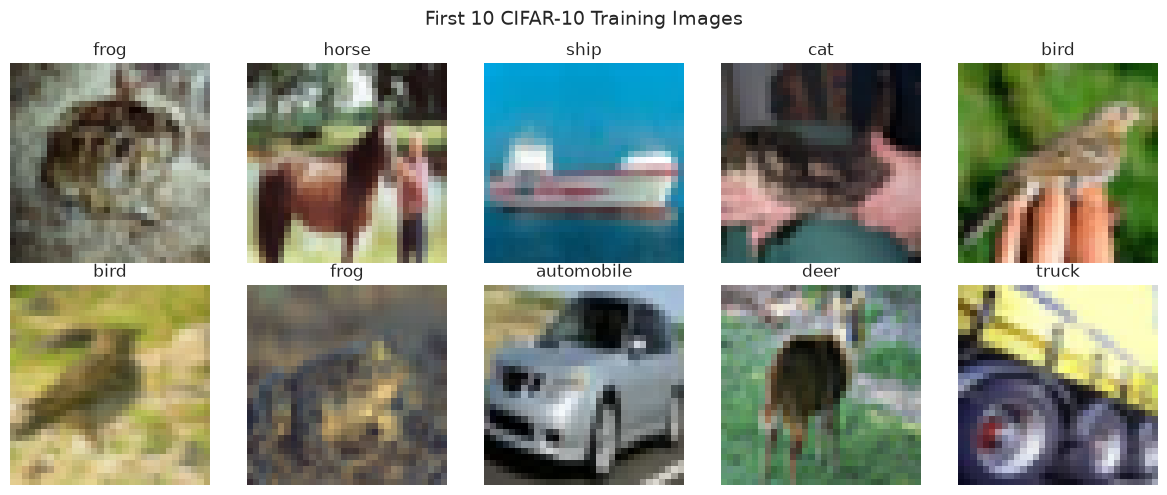

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = X_train[i].reshape(3, 32, 32).transpose(1, 2, 0).astype('uint8')
    ax.imshow(img)
    ax.set_title(f"{class_names[y_train[i]]}", fontsize=12)
    ax.axis('off')

plt.suptitle("First 10 CIFAR-10 Training Images", fontsize=14)
plt.tight_layout()
plt.show()

### 3.2 Class Distribution

Are the 10 classes balanced in the training set?

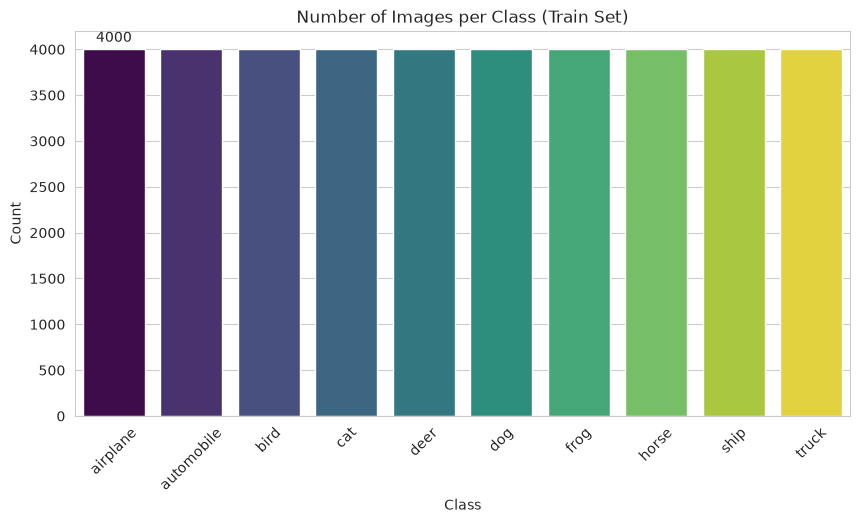

Class distribution (%):
0    10.0
1    10.0
2    10.0
3    10.0
4    10.0
5    10.0
6    10.0
7    10.0
8    10.0
9    10.0
Name: count, dtype: float64


In [5]:
class_counts = pd.Series(y_train).value_counts().sort_index()

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x=[class_names[i] for i in class_counts.index],
    y=class_counts.values,
    hue=class_counts.index,
    palette='viridis',
    legend=False
)

plt.title('Number of Images per Class (Train Set)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
ax.bar_label(ax.containers[0], padding=3)
plt.show()

print("Class distribution (%):")
print((class_counts / class_counts.sum() * 100).round(2))

`All 10 classes are perfectly balanced (5,000 images each in the original dataset), so we don't need to worry about class imbalance.`

### 3.3 Pixel Intensity Distribution

CIFAR-10 images are natural photos, so pixel intensities are spread across the full [0, 255] range (unlike MNIST's mostly-black background). This will guide our normalization step.

In [ ]:
plt.figure(figsize=(10, 4))
sns.histplot(X_train.flatten(), bins=50, color='steelblue')
plt.title('Pixel Intensity Distribution (All Training Images)')
plt.xlabel('Pixel value (0=dark, 255=bright)')
plt.ylabel('Frequency')
plt.yscale('log')
plt.show()

## 4. Data Preprocessing

The pixel data from the CSV is already flattened (3072 columns per image), so unlike MNIST there's no reshaping step needed. We just need to:
1. **Normalize** pixel values from [0, 255] to [0, 1] so gradients behave nicely.

Labels are already integers (0-9) - we'll keep them as-is and use `sparse_categorical_crossentropy` as the loss.

### 4.1 Normalize

In [ ]:
n_features = X_train.shape[1]  # 3072 (32 x 32 x 3)
n_classes  = 10

X_train_scaled = X_train.astype('float32') / 255.0
X_test_scaled  = X_test.astype('float32')  / 255.0

print("X_train_scaled shape :", X_train_scaled.shape)
print("X_test_scaled  shape :", X_test_scaled.shape)
print("New pixel range      :", X_train_scaled.min(), "to", X_train_scaled.max())

X_train_scaled shape : (40000, 3072)
X_test_scaled  shape : (10000, 3072)
New pixel range      : 0.0 to 1.0


## 5. Build the ANN

A 3-hidden-layer fully connected network (512 -> 256 -> 128) with `BatchNormalization` and `Dropout` for regularization. CIFAR-10 images are more complex than MNIST digits (color, natural scenes), so we use wider layers. The output layer has 10 neurons with `softmax` activation - one probability per class.

In [8]:
model = Sequential()

# Input layer
model.add(Input(shape=(n_features,)))

model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Output layer - 10 classes
model.add(Dense(n_classes, activation='softmax'))

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

E0000 00:00:1787285585.489162   14622 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,742,474 (6.65 MB)

 Trainable params: 1,740,682 (6.64 MB)

 Non-trainable params: 1,792 (7.00 KB)

## 6. Train the Model

`EarlyStopping` halts training once the validation loss stops improving and restores the best weights. We hold out 10% of the training data as a validation set.

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=5,
    verbose=1,
    mode="min",
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30



  1/282 ━━━━━━━━━━━━━━━━━━━━ 8:30 2s/step - accuracy: 0.1094 - loss: 3.6093


  5/282 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.1562 - loss: 3.0831


  9/282 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.1510 - loss: 2.9604


 12/282 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.1582 - loss: 2.9066

...


276/282 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4428 - loss: 1.5628


279/282 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4430 - loss: 1.5623


282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.4428 - loss: 1.5626 - val_accuracy: 0.4363 - val_loss: 1.5603


Epoch 20: early stopping


Restoring model weights from the end of the best epoch: 15.


## 7. Training History

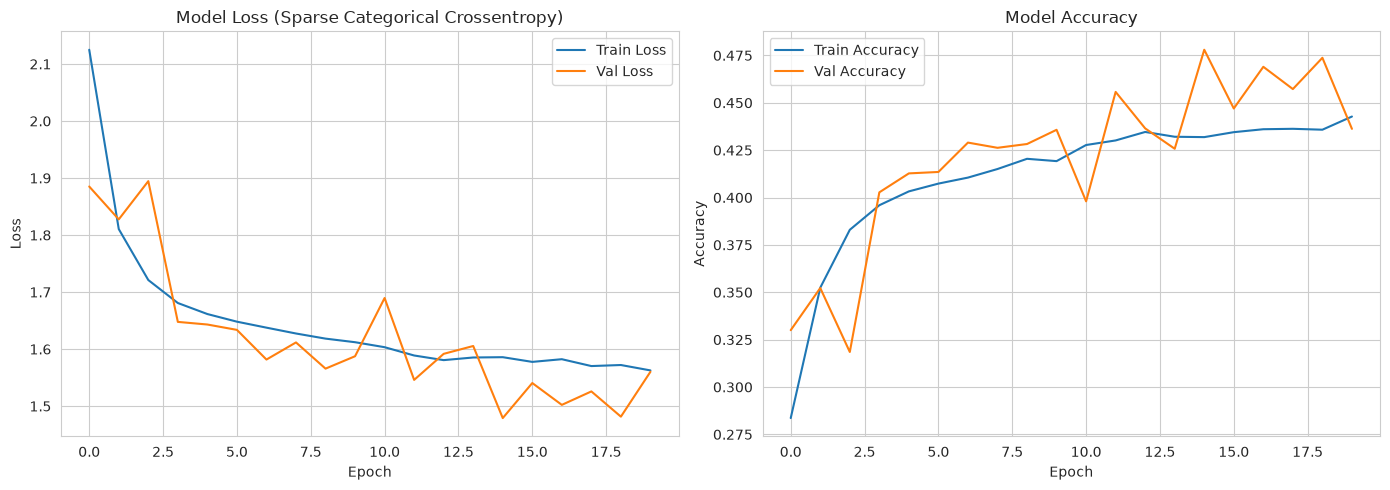

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Model Loss (Sparse Categorical Crossentropy)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Evaluate on Test Set

### 8.1 Overall Accuracy & Loss

In [11]:
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

Test Loss     : 1.4977
Test Accuracy : 0.4685


### 8.2 Predict on Test Set

In [12]:
y_pred_proba = model.predict(X_test_scaled, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

for actual, pred in zip(y_test[10:20], y_pred[10:20]):
    mark = 'OK' if actual == pred else 'X'
    print(f"Actual: {class_names[actual]:<10}   Predicted: {class_names[pred]:<10}   [{mark}]")

Actual: automobile   Predicted: automobile   [OK]
Actual: ship         Predicted: dog          [X]
Actual: horse        Predicted: horse        [OK]
Actual: truck        Predicted: dog          [X]
Actual: airplane     Predicted: airplane     [OK]
Actual: frog         Predicted: frog         [OK]
Actual: cat          Predicted: cat          [OK]
Actual: dog          Predicted: frog         [X]
Actual: horse        Predicted: dog          [X]
Actual: truck        Predicted: truck        [OK]


### 8.3 Classification Report

Per-class precision, recall and F1-score.

In [13]:
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

              precision    recall  f1-score   support

    airplane     0.5699    0.4810    0.5217      1000
  automobile     0.5985    0.5440    0.5699      1000
        bird     0.3378    0.3540    0.3457      1000
         cat     0.3896    0.2030    0.2669      1000
        deer     0.3626    0.4830    0.4142      1000
         dog     0.4664    0.3190    0.3789      1000
        frog     0.4381    0.5950    0.5047      1000
       horse     0.4383    0.5820    0.5000      1000
        ship     0.6167    0.6050    0.6108      1000
       truck     0.5216    0.5190    0.5203      1000

    accuracy                         0.4685     10000
   macro avg     0.4739    0.4685    0.4633     10000
weighted avg     0.4739    0.4685    0.4633     10000



### 8.4 Confusion Matrix

Rows = true class, columns = predicted class. Diagonal = correct predictions; off-diagonal cells show the most common mistakes (e.g. cat vs dog, automobile vs truck).

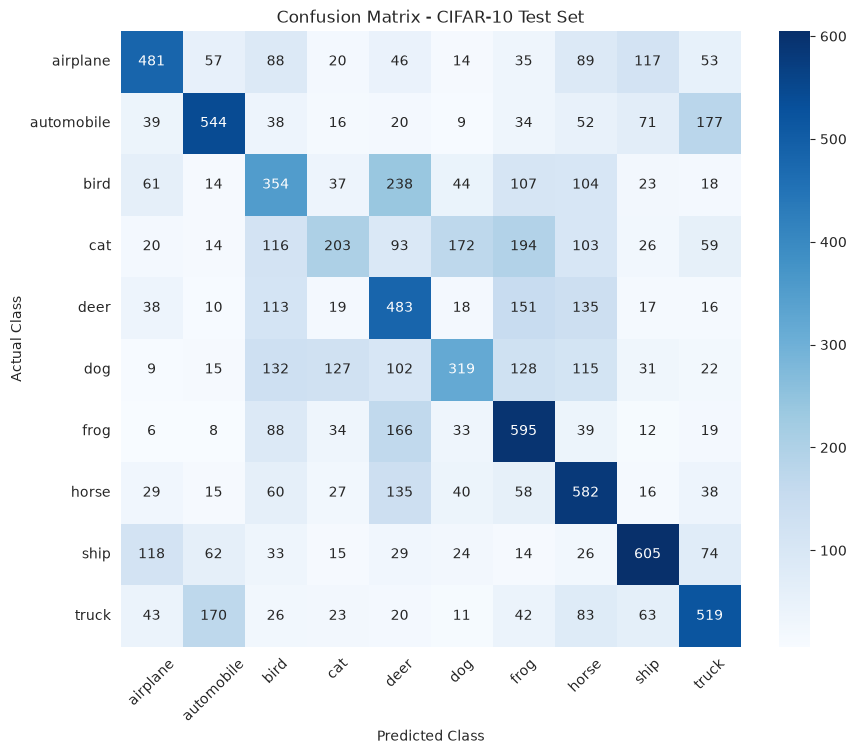

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True
)
plt.title('Confusion Matrix - CIFAR-10 Test Set')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

## 9. Inference on a Single Image

Helper that takes any 32x32x3 image, applies the same normalize pipeline, then returns the predicted class and the per-class probabilities. We demonstrate it on an image from the (unlabeled) `Cifar_data/test.csv` competition file.

In [15]:
def inference(model, img_array):
    # Preprocess the image (expects a flat 3072-length array, 0-255 range)
    img_flat = img_array.reshape(1, -1).astype('float32') / 255.0

    # Predict
    pred_proba = model.predict(img_flat, verbose=0)
    pred_class = np.argmax(pred_proba, axis=1)[0]
    pred_confidence = np.max(pred_proba)

    print(f"Predicted class: {class_names[pred_class]}\n")
    print(f"Prediction confidence: {pred_confidence:.4f}\n")
    return pred_class, pred_proba

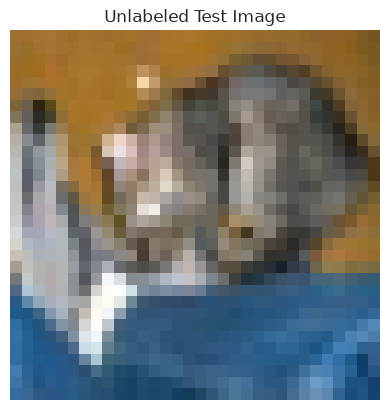

Predicted class: cat

Prediction confidence: 0.2289



(np.int64(3),
 array([[0.04541779, 0.07862469, 0.08269554, 0.2288835 , 0.09995104,
         0.21273053, 0.12189452, 0.02228167, 0.09004866, 0.01747195]],
       dtype=float32))

In [16]:
df_test = pd.read_csv("Cifar_data/test.csv")
sample = df_test.iloc[0].values

img = sample.reshape(3, 32, 32).transpose(1, 2, 0).astype('uint8')
plt.imshow(img)
plt.title("Unlabeled Test Image")
plt.axis('off')
plt.show()

inference(model, sample)